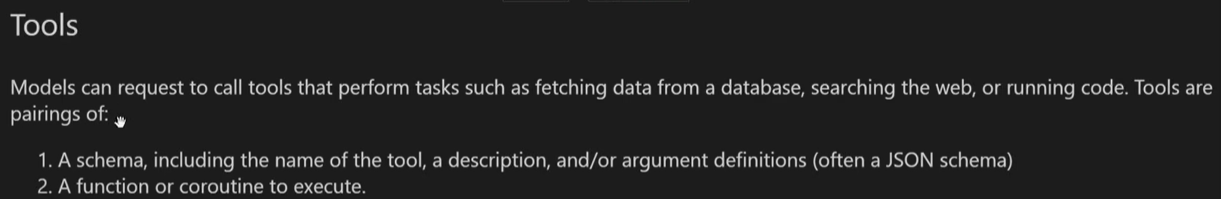

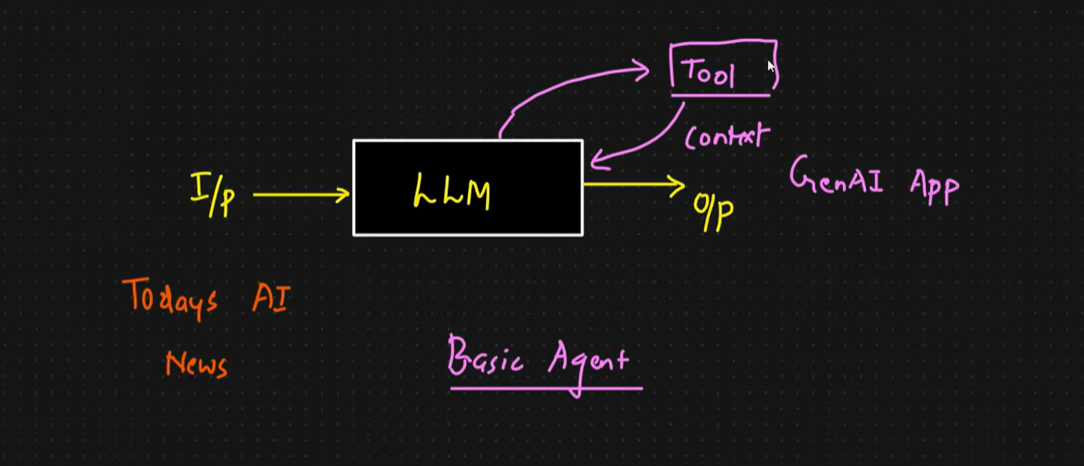

In [18]:
import os
from langchain.chat_models import init_chat_model
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = init_chat_model("groq:openai/gpt-oss-120b")
response = model.invoke("How to build ai agents")
response.content


'Below is a practical, step‑by‑step roadmap for building **AI agents**—software entities that can perceive their environment, reason, and take actions on your behalf.  \nThe guide is organized into three layers:\n\n| Layer | What it covers | Typical tools / libraries |\n|-------|----------------|---------------------------|\n| **1️⃣ Core Foundations** | Data, model selection, training, inference | Python, PyTorch / TensorFlow, Hugging Face 🤗 Transformers, LangChain, OpenAI API |\n| **2️⃣ Agent Architecture** | Memory, planning, tool use, multi‑step reasoning | ReAct, Retrieval‑Augmented Generation (RAG), tool‑calling APIs, vector stores |\n| **3️⃣ Deployment & Safety** | APIs, containers, monitoring, guardrails | FastAPI / Flask, Docker, Kubernetes, LangChain‑Serve, OpenAI moderation, RLHF |\n\n---\n\n## 1️⃣ Core Foundations\n\n### 1.1 Define the Agent’s Purpose & Scope\n| Question | Why it matters |\n|----------|----------------|\n| **What problem does the agent solve?** (e.g., schedu

In [12]:
from langchain.tools import tool

@tool
def get_weather(location:str)->str:
    """ Get the weather at a given location """
    return(f"Its sunny in {location}")

model_with_tools = model.bind_tools([get_weather])
#  ALternate to create agent and connect tool with llm
#  agent = create_agent(
#     model=llm,
#     tools=[get_weather],
#     system_prompt="You are a helpful AI assistant",
# )

This tool library which we imported will be used as a decorator. SO when we use this decorator ontop of any function it becomes a tool in langchain

In [15]:
response = model_with_tools.invoke("WHats weather like in Galway?")
print(response)
for tool_call in response.tool_calls:
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")

content='' additional_kwargs={'reasoning_content': 'The user asks: "WHats weather like in Galway?" We need to provide current weather. Use function get_weather with location "Galway".', 'tool_calls': [{'id': 'fc_fc268b1f-404e-42bf-acf1-0a6cc5031fc5', 'function': {'arguments': '{"location":"Galway"}', 'name': 'get_weather'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 128, 'total_tokens': 186, 'completion_time': 0.125738112, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.006850429, 'prompt_tokens_details': None, 'queue_time': 0.153949886, 'total_time': 0.132588541}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_0708ac49a5', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a097ab-f320-75e0-84c2-8e4609a5d6b8-0' tool_calls=[{'name': 'get_weather', 'args': {'location': 'Galway'}, 'id': 'fc_fc268b1f-404e-42bf-acf1-0a6cc5031fc5',

### Tool Execution loops

In [16]:
# Step 1: Model generates tool calls
messages = [{"role": "user", "content": "What's the weather in Boston?"}]
ai_msg = model_with_tools. invoke(messages)
messages.append(ai_msg)

# Step 2: Execute tools and collect results
for tool_call in ai_msg.tool_calls:
# Execute the tool with the generated arguments
    tool_result = get_weather. invoke(tool_call)
    messages. append(tool_result)

# Step 3: Pass results back to model for final response
final_response = model_with_tools.invoke(messages)
print(final_response.text)

It’s sunny in Boston right now! Enjoy the clear skies.


In [17]:
messages

[{'role': 'user', 'content': "What's the weather in Boston?"},
 AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to fetch weather using function. Use get_weather with location "Boston".', 'tool_calls': [{'id': 'fc_f215ce27-739a-4d52-9b95-f878e2c76300', 'function': {'arguments': '{"location":"Boston"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 127, 'total_tokens': 171, 'completion_time': 0.092063986, 'completion_tokens_details': {'reasoning_tokens': 17}, 'prompt_time': 0.004857716, 'prompt_tokens_details': None, 'queue_time': 0.048859533, 'total_time': 0.096921702}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_f640395b96', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a097b0-dd1c-75f1-887c-cb80480161a0-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Boston'}, 'id': 'fc_f215ce27-73